<a href="https://colab.research.google.com/github/yaelglz/modelos-estocasticos-toma-decisiones/blob/main/expo/expo_regresion_logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Roberto Isaac Polo Alonzo
* Valeria Hernandez Varillas
* Yael Abraham Gonzalez Muñoz

# Educación: Abandono Escolar

In [ ]:
import pandas as pd
import matplotlib.pyplot as pltS
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


### 1. Carga y Preparación de Datos

En esta sección cargamos la base de datos de estudiantes y preparamos todas las variables, incluyendo la conversión de variables categóricas (`Ingreso_Familiar`) a numéricas para el modelo.


In [ ]:
estudiantes = [
    {"ID": "EST-001", "Asistencia": 85, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 10},
    {"ID": "EST-002", "Asistencia": 92, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-003", "Asistencia": 68, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 30},
    {"ID": "EST-004", "Asistencia": 95, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-005", "Asistencia": 72, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 25},
    {"ID": "EST-006", "Asistencia": 90, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 8},
    {"ID": "EST-007", "Asistencia": 78, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 20},
    {"ID": "EST-008", "Asistencia": 88, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 12},
    {"ID": "EST-009", "Asistencia": 61, "Materias_Reprobadas": 4, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 40},
    {"ID": "EST-010", "Asistencia": 94, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-011", "Asistencia": 70, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 35},
    {"ID": "EST-012", "Asistencia": 89, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 5},
    {"ID": "EST-013", "Asistencia": 83, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 15},
    {"ID": "EST-014", "Asistencia": 65, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 30},
    {"ID": "EST-015", "Asistencia": 91, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-016", "Asistencia": 74, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 20},
    {"ID": "EST-017", "Asistencia": 86, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 10},
    {"ID": "EST-018", "Asistencia": 93, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-019", "Asistencia": 55, "Materias_Reprobadas": 5, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 45},
    {"ID": "EST-020", "Asistencia": 80, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 18},
    {"ID": "EST-021", "Asistencia": 87, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 12},
    {"ID": "EST-022", "Asistencia": 96, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-023", "Asistencia": 69, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 28},
    {"ID": "EST-024", "Asistencia": 76, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 22},
    {"ID": "EST-025", "Asistencia": 91, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-026", "Asistencia": 84, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 14},
    {"ID": "EST-027", "Asistencia": 62, "Materias_Reprobadas": 4, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 38},
    {"ID": "EST-028", "Asistencia": 89, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 6},
    {"ID": "EST-029", "Asistencia": 73, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 24},
    {"ID": "EST-030", "Asistencia": 95, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-031", "Asistencia": 79, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 16},
    {"ID": "EST-032", "Asistencia": 58, "Materias_Reprobadas": 4, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 42},
    {"ID": "EST-033", "Asistencia": 88, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 10},
    {"ID": "EST-034", "Asistencia": 92, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-035", "Asistencia": 66, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 32},
    {"ID": "EST-036", "Asistencia": 82, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 15},
    {"ID": "EST-037", "Asistencia": 75, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 20},
    {"ID": "EST-038", "Asistencia": 90, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 4},
    {"ID": "EST-039", "Asistencia": 60, "Materias_Reprobadas": 5, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 40},
    {"ID": "EST-040", "Asistencia": 94, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-041", "Asistencia": 81, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 12},
    {"ID": "EST-042", "Asistencia": 71, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 30},
    {"ID": "EST-043", "Asistencia": 87, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 8},
    {"ID": "EST-044", "Asistencia": 97, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-045", "Asistencia": 64, "Materias_Reprobadas": 3, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 35},
    {"ID": "EST-046", "Asistencia": 83, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 14},
    {"ID": "EST-047", "Asistencia": 77, "Materias_Reprobadas": 2, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 22},
    {"ID": "EST-048", "Asistencia": 93, "Materias_Reprobadas": 0, "Ingreso_Familiar": "Alto", "Horas_Trabajadas_Semanales": 0},
    {"ID": "EST-049", "Asistencia": 57, "Materias_Reprobadas": 4, "Ingreso_Familiar": "Bajo", "Horas_Trabajadas_Semanales": 45},
    {"ID": "EST-050", "Asistencia": 85, "Materias_Reprobadas": 1, "Ingreso_Familiar": "Medio", "Horas_Trabajadas_Semanales": 10}
]

df = pd.DataFrame(estudiantes)

# Definir variable objetivo 'Abandono'
df['Abandono'] = ((df['Materias_Reprobadas'] > 2) | (df['Asistencia'] < 70)).astype(int)

# Mapeo manual de Ingreso_Familiar a números
# Bajo = 1, Medio = 2, Alto = 3
mapeo_ingreso = {"Bajo": 1, "Medio": 2, "Alto": 3}
df['Ingreso_Numerico'] = df['Ingreso_Familiar'].map(mapeo_ingreso)

print(df[['ID', 'Ingreso_Familiar', 'Ingreso_Numerico']].head())


        ID Ingreso_Familiar  Ingreso_Numerico
0  EST-001            Medio                 2
1  EST-002             Alto                 3
2  EST-003             Bajo                 1
3  EST-004             Alto                 3
4  EST-005             Bajo                 1


### 2. Visualización

Analizamos visualmente cómo afectan las `Horas_Trabajadas_Semanales` y la `Asistencia` al riesgo de abandono.


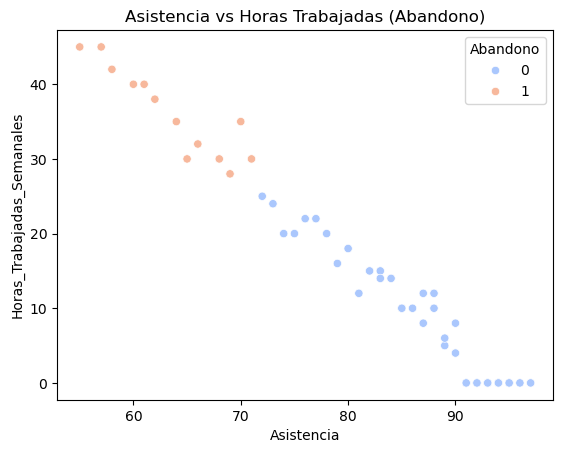

In [ ]:
sns.scatterplot(data=df, x='Asistencia', y='Horas_Trabajadas_Semanales', hue='Abandono', palette='coolwarm')
plt.title('Asistencia vs Horas Trabajadas (Abandono)')
plt.show()


### 3. Entrenar el Modelo

Entrenamos la Regresión Logística utilizando todas las variables disponibles en el dataset.


In [ ]:
# Definir X (todas las variables predictoras) y y
# Usamos el Ingreso_Numerico (1, 2, 3) directamente
X = df[['Asistencia', 'Materias_Reprobadas', 'Horas_Trabajadas_Semanales', 'Ingreso_Numerico']]
y = df['Abandono']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Crear y ajustar el modelo
modelo = LogisticRegression(max_iter=100)
modelo.fit(X_train, y_train)


LogisticRegression()

### 4. Evaluar el Modelo

Evaluamos el desempeño del modelo con una matriz de confusión y el reporte de métricas.


In [ ]:
y_pred = modelo.predict(X_test)
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Matriz de Confusión:
[[11  0]
 [ 0  4]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



### 5. Probabilidades

Visualizamos las probabilidades de abandono calculadas para los estudiantes del conjunto de prueba.


In [ ]:
probabilidades = modelo.predict_proba(X_test)
resultados = X_test.copy()
resultados['Prob_Abandono'] = probabilidades[:, 1]
resultados['Predicción'] = y_pred
print(resultados.head())


    Asistencia  Materias_Reprobadas  Horas_Trabajadas_Semanales  \
13          65                    3                          30   
39          94                    0                           0   
30          79                    1                          16   
45          83                    1                          14   
17          93                    0                           0   

    Ingreso_Numerico  Prob_Abandono  Predicción  
13                 1   9.973122e-01           1  
39                 3   2.998229e-13           0  
30                 2   2.492199e-05           0  
45                 2   9.377197e-07           0  
17                 3   4.836957e-13           0  


### 6. Interpretar Coeficientes

Analizamos la influencia de cada variable en la probabilidad de abandono. Un coeficiente negativo en 'Ingreso_Numerico' indicaría que a mayor nivel de ingreso (subiendo de 1 a 3), menor es el riesgo de abandono.


In [ ]:
coeficientes = pd.DataFrame({
    'Variable': ['Intercepto'] + X.columns.tolist(),
    'Coeficiente': [modelo.intercept_[0]] + modelo.coef_[0].tolist()
})
print(coeficientes)


                     Variable  Coeficiente
0                  Intercepto    16.121834
1                  Asistencia    -0.478264
2         Materias_Reprobadas     0.125507
3  Horas_Trabajadas_Semanales     0.683511
4            Ingreso_Numerico    -0.000199


| Variable | Coeficiente | Interpretación                      |
|:---------|:-----------:|:------------------------------------|
| Intercepto |  16.121834  | Valor base del modelo               |
| Asistencia |  -0.478264  | Mayor asistencia = menor riesgo     |
| Materias_Reprobadas |  0.125507   | Más materias = mayor riesgo         |
| Horas_Trabajadas_Semanales |  0.683511   | Más trabajo = mayor riesgo (FUERTE) |
| Ingreso_Numerico |  -0.000199  | Impacto nulo                        |

---
## Casos Prácticos con el Modelo Entrenado

En estos ejemplos, utilizaremos el modelo de regresión logística ya entrenado para predecir la probabilidad de abandono de tres perfiles de estudiantes diferentes basados en la base de datos original.

### Ejemplo 1: Estudiante de Alto Riesgo
Perfil: Baja asistencia (60%), 4 materias reprobadas, trabaja 40 horas e ingreso bajo (1).


In [ ]:
# Definir el perfil del estudiante
# Variables: Asistencia, Materias_Reprobadas, Horas_Trabajadas_Semanales, Ingreso_Numerico
nuevo_estudiante_1 = pd.DataFrame([[60, 4, 40, 1]], columns=X.columns)

# Predecir probabilidad
prob_1 = modelo.predict_proba(nuevo_estudiante_1)
pred_1 = modelo.predict(nuevo_estudiante_1)

print(f"Probabilidad de Abandono: {prob_1[0][1]:.4f}")
print(f"Predicción final: {'Abandona' if pred_1[0] == 1 else 'Se queda'}")


Probabilidad de Abandono: 1.0000
Predicción final: Abandona


**Interpretación:** Este estudiante presenta múltiples factores de riesgo. La baja asistencia combinada con la carga laboral y académica (materias reprobadas) resulta en una probabilidad de abandono muy alta, lo que sugiere una intervención inmediata.

### Ejemplo 2: Estudiante de Riesgo Moderado
Perfil: Asistencia regular (63%), 2 materias reprobadas, trabaja 20 horas e ingreso medio (2).


In [ ]:
nuevo_estudiante_2 = pd.DataFrame([[63, 2, 20, 2]], columns=X.columns)

prob_2 = modelo.predict_proba(nuevo_estudiante_2)
pred_2 = modelo.predict(nuevo_estudiante_2)

print(f"Probabilidad de Abandono: {prob_2[0][1]:.4f}")
print(f"Predicción final: {'Abandona' if pred_2[0] == 1 else 'Se queda'}")


Probabilidad de Abandono: 0.4780
Predicción final: Se queda


**Interpretación:** Aunque el estudiante aún no cae en la categoría de abandono inminente, su probabilidad es significativa. Se recomienda un seguimiento académico para evitar que repruebe más materias.

### Ejemplo 3: Estudiante de Bajo Riesgo
Perfil: Alta asistencia (95%), 0 materias reprobadas, no trabaja e ingreso alto (3).


In [ ]:
nuevo_estudiante_3 = pd.DataFrame([[95, 0, 0, 3]], columns=X.columns)

prob_3 = modelo.predict_proba(nuevo_estudiante_3)
pred_3 = modelo.predict(nuevo_estudiante_3)

print(f"Probabilidad de Abandono: {prob_3[0][1]:.4f}")
print(f"Predicción final: {'Abandona' if pred_3[0] == 1 else 'Se queda'}")


Probabilidad de Abandono: 0.0000
Predicción final: Se queda


**Interpretación:** El estudiante muestra indicadores de estabilidad académica y financiera. La probabilidad de abandono es mínima, lo que indica un perfil con altas posibilidades de éxito escolar.
